<a href="https://colab.research.google.com/github/mohany606/RFM-Analysis-task-NTI/blob/main/task_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Business Understanding
This is a transactional data set which contains all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail.

**Important Additional Variable Information**


  > **InvoiceNo**: Invoice number. Nominal, a 6-digit integral number uniquely assigned to each transaction. If this code starts with letter 'c', it indicates a cancellation.

  >  **StockCode**: Product (item) code. Nominal, a 5-digit integral number uniquely assigned to each distinct product.

  > **Quantity**: The quantities of each product (item) per transaction. Numeric.

  > **UnitPrice**: Unit price. Numeric, Product price per unit in sterling.

  > **CustomerID**: Customer number. Nominal, a 5-digit integral number uniquely assigned to each customer.


# Exploratory Data Analysis (EDA) & Feature Engineering


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_excel('/content/Online Retail.xlsx')

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


The big percentage of the nulls in the CustomerID referes to not signed in users

 dealing with it the best way is **unfortunately droping** them because the target is **RFM analysis**

In [ ]:
df.dropna(subset=['CustomerID'],inplace=True)

In [ ]:
df_copy = df.copy()

In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['InvoiceYear'] = df['InvoiceDate'].dt.year
df['InvoiceMonth'] = df['InvoiceDate'].dt.month
df['InvoiceDay'] = df['InvoiceDate'].dt.day
df['Hour'] = df['InvoiceDate'].dt.hour
df['Weekday'] = df['InvoiceDate'].dt.day_name()
df.drop(columns='InvoiceDate',inplace = True)
display(df[[ 'InvoiceYear', 'InvoiceMonth', 'InvoiceDay']].head())

,InvoiceYear,InvoiceMonth,InvoiceDay
0,2010,12,1
1,2010,12,1
2,2010,12,1
3,2010,12,1
4,2010,12,1


In [ ]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [ ]:
df['IsCancellation'] = (df['Quantity'] < 0) | (df['InvoiceNo'].astype(str).str.startswith('C', na=False))

In [ ]:
sales_df = df[~df['IsCancellation'] & (df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()
returns_df = df[df['IsCancellation']].copy()


# we need that feature (CustomerID) for the RFM feature Extraction , so i won't encode it

In [ ]:
df['CustomerID'].nunique()

4372

In [ ]:
df['StockCode'].nunique()

3684

# Applying K-fold target encoding for the feature of StockCode

In [ ]:

overall_mean_unit_price = df['UnitPrice'].mean()
df.reset_index(drop=True, inplace=True)
df['StockCode_TargetEncoded'] = np.nan

# Initialize KFold with 5 splits
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Get the column index for 'StockCode_TargetEncoded' for iloc assignment
df_col_idx = df.columns.get_loc('StockCode_TargetEncoded')

for train_index, val_index in kf.split(df):
    # Use iloc for slicing as df now has a RangeIndex and KFold returns integer positions
    X_train, X_val = df.iloc[train_index], df.iloc[val_index]
    target_mean_map = X_train.groupby('StockCode')['UnitPrice'].mean()
    df.iloc[val_index, df_col_idx] = X_val['StockCode'].map(target_mean_map).fillna(overall_mean_unit_price)

print("DataFrame with K-fold Target Encoded StockCode:")
display(df[['StockCode', 'UnitPrice', 'StockCode_TargetEncoded']].head())

DataFrame with K-fold Target Encoded StockCode:


,StockCode,UnitPrice,StockCode_TargetEncoded
0,85123A,2.55,2.891525
1,71053,3.39,3.764587
2,84406B,2.75,3.838137
3,84029G,3.39,4.014338
4,84029E,3.39,4.063216


In [ ]:
df.describe()

,Quantity,UnitPrice,CustomerID,InvoiceYear,InvoiceMonth,InvoiceDay,Hour,Revenue,StockCode_TargetEncoded
count,406829.000000,406829.000000,406829.000000,406829.000000,406829.000000,406829.000000,406829.000000,406829.000000,406829.000000
mean,12.061303,3.460471,15287.690570,2010.934002,7.605947,15.036128,12.737472,20.401854,3.458528
std,248.693370,69.315162,1713.600303,0.248279,3.418942,8.653730,2.284952,427.591718,13.455785
min,-80995.000000,0.000000,12346.000000,2010.000000,1.000000,1.000000,6.000000,-168469.600000,0.000667
25%,2.000000,1.250000,13953.000000,2011.000000,5.000000,7.000000,11.000000,4.200000,1.239653
50%,5.000000,1.950000,15152.000000,2011.000000,8.000000,15.000000,13.000000,11.100000,1.944742
75%,12.000000,3.750000,16791.000000,2011.000000,11.000000,22.000000,14.000000,19.500000,3.750000
max,80995.000000,38970.000000,18287.000000,2011.000000,12.000000,31.000000,20.000000,168469.600000,855.262500


# Insights and visuals

# **1. Top Products (Units Sold vs. Revenue):**

/tmp/ipykernel_2080/1028583855.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_units, y=prod_col, x='Quantity', ax=axes[0], palette='Blues_r')
/tmp/ipykernel_2080/1028583855.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_rev, y=prod_col, x='Revenue', ax=axes[1], palette='Greens_r')


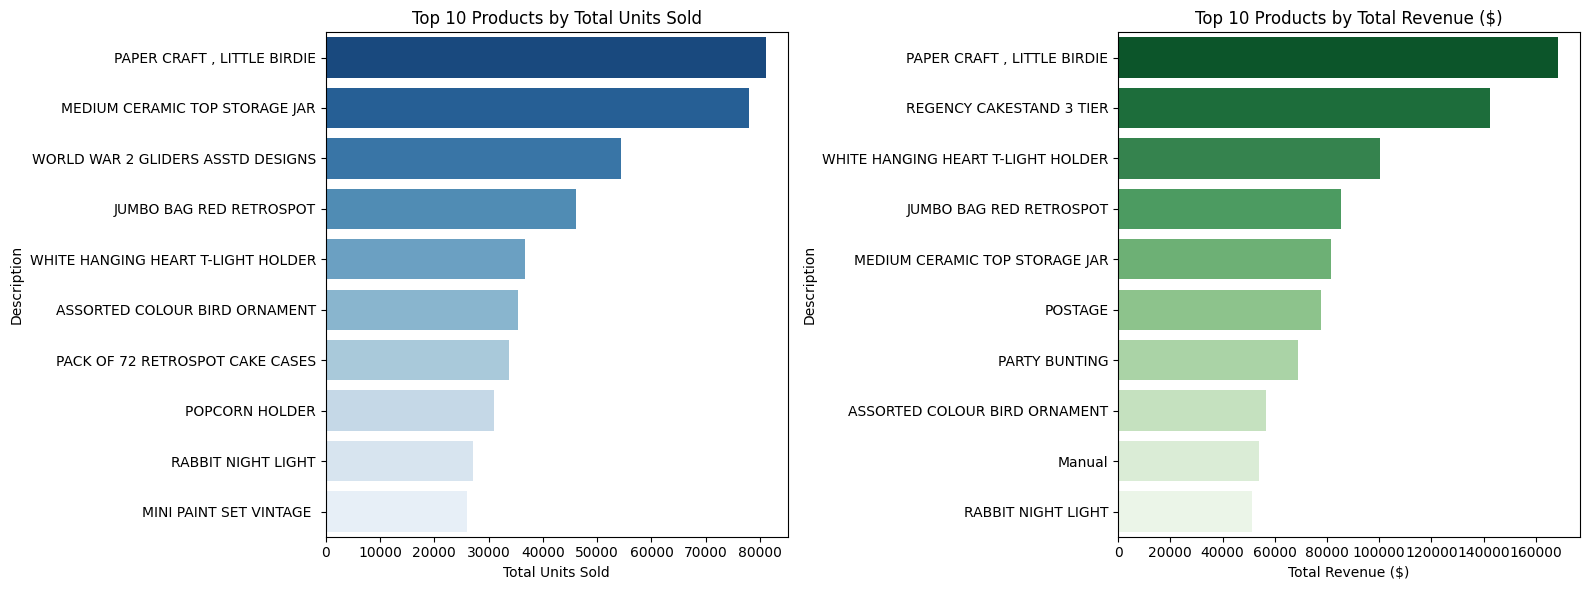

In [ ]:
# @title
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Identify Product column (Description if available, else StockCode)
prod_col = 'Description' if 'Description' in sales_df.columns else 'StockCode'

# Top by Units Sold
top_units = sales_df.groupby(prod_col)['Quantity'].sum().nlargest(10).reset_index()
sns.barplot(data=top_units, y=prod_col, x='Quantity', ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 10 Products by Total Units Sold')
axes[0].set_xlabel('Total Units Sold')

# Top by Revenue
top_rev = sales_df.groupby(prod_col)['Revenue'].sum().nlargest(10).reset_index()
sns.barplot(data=top_rev, y=prod_col, x='Revenue', ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 10 Products by Total Revenue ($)')
axes[1].set_xlabel('Total Revenue ($)')

plt.tight_layout()
plt.show()

# **2. Top Customers (Revenue & Orders)**

/tmp/ipykernel_2080/3962656347.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_cust_rev, x='TotalRevenue', y='CustomerID', ax=axes[0], palette='Purples_r')
/tmp/ipykernel_2080/3962656347.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_cust_orders, x='TotalOrders', y='CustomerID', ax=axes[1], palette='Oranges_r')


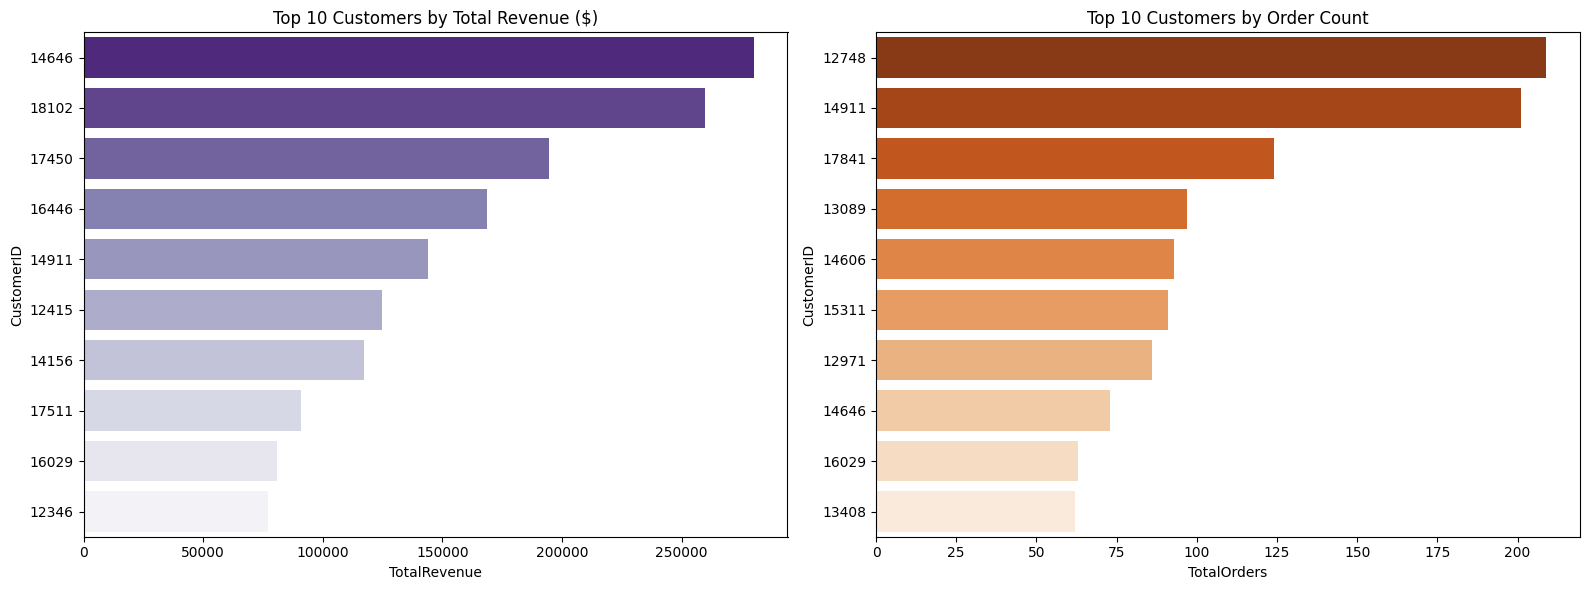

In [ ]:
# @title
# Filter out missing CustomerIDs for customer-level queries
cust_df = sales_df.dropna(subset=['CustomerID']).copy()
cust_df['CustomerID'] = cust_df['CustomerID'].astype(int).astype(str)

cust_summary = cust_df.groupby('CustomerID').agg(
    TotalRevenue=('Revenue', 'sum'),
    TotalOrders=('InvoiceNo', 'nunique')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top Customers by Revenue
top_cust_rev = cust_summary.nlargest(10, 'TotalRevenue')
sns.barplot(data=top_cust_rev, x='TotalRevenue', y='CustomerID', ax=axes[0], palette='Purples_r')
axes[0].set_title('Top 10 Customers by Total Revenue ($)')

# Top Customers by Order Count
top_cust_orders = cust_summary.nlargest(10, 'TotalOrders')
sns.barplot(data=top_cust_orders, x='TotalOrders', y='CustomerID', ax=axes[1], palette='Oranges_r')
axes[1].set_title('Top 10 Customers by Order Count')

plt.tight_layout()
plt.show()

# **3. Revenue Trends & Seasonal Patterns**

In [ ]:
df['YearMonth'] = df_copy['InvoiceDate'].dt.to_period('M').astype(str)

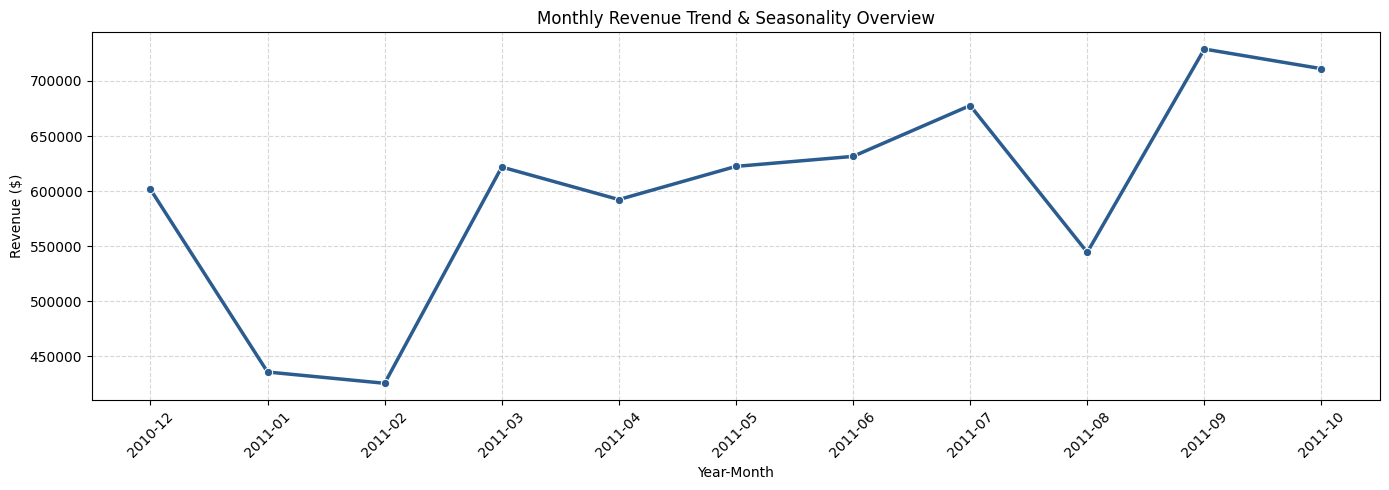

In [ ]:
# @title
plt.figure(figsize=(14, 5))

# Monthly Revenue Trend
monthly_rev = sales_df.groupby('YearMonth')['Revenue'].sum().reset_index()
sns.lineplot(data=monthly_rev, x='YearMonth', y='Revenue', marker='o', color='#2b5c8f', linewidth=2.5)
plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend & Seasonality Overview')
plt.ylabel('Revenue ($)')
plt.xlabel('Year-Month')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# **4. Peak Activity (Months, Weekdays, and Hours)**

/tmp/ipykernel_2080/1293956050.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_sales, x='InvoiceMonth', y='Revenue', ax=axes[0], palette='crest')
/tmp/ipykernel_2080/1293956050.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weekday_sales, x='Weekday', y='Revenue', ax=axes[1], palette='viridis')


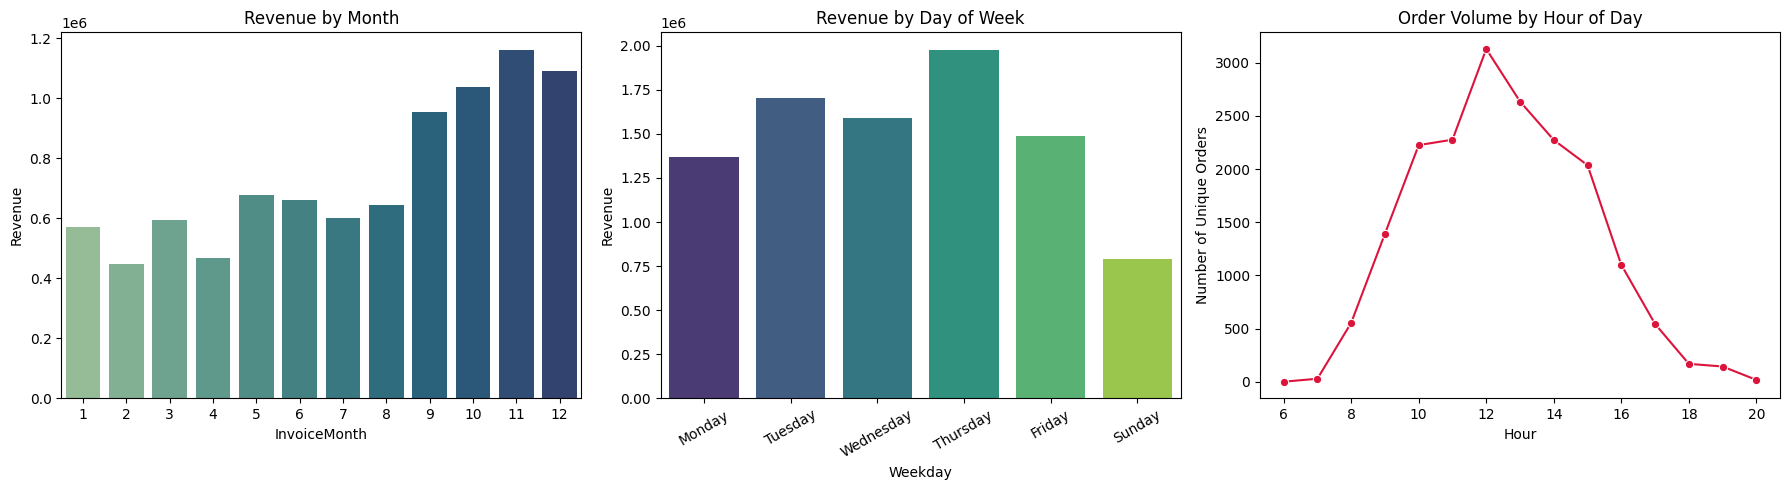

In [ ]:
# @title
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# By Month
monthly_sales = sales_df.groupby('InvoiceMonth')['Revenue'].sum().reset_index()
sns.barplot(data=monthly_sales, x='InvoiceMonth', y='Revenue', ax=axes[0], palette='crest')
axes[0].set_title('Revenue by Month')

# By Weekday (if datetime available)
if 'Weekday' in sales_df.columns:
    days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    weekday_sales = sales_df.groupby('Weekday')['Revenue'].sum().reindex(days_order).dropna().reset_index()
    sns.barplot(data=weekday_sales, x='Weekday', y='Revenue', ax=axes[1], palette='viridis')
    axes[1].set_title('Revenue by Day of Week')
    axes[1].tick_params(axis='x', rotation=30)

# By Hour (if datetime available)
if 'Hour' in sales_df.columns:
    hourly_orders = sales_df.groupby('Hour')['InvoiceNo'].nunique().reset_index()
    sns.lineplot(data=hourly_orders, x='Hour', y='InvoiceNo', ax=axes[2], marker='o', color='crimson')
    axes[2].set_title('Order Volume by Hour of Day')
    axes[2].set_ylabel('Number of Unique Orders')

plt.tight_layout()
plt.show()

/tmp/ipykernel_2080/304046224.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=country_ex_uk, y='Country', x='Revenue', ax=axes[0], palette='Blues_r')
/tmp/ipykernel_2080/304046224.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=country_ex_uk, y='Country', x='Orders', ax=axes[1], palette='Greens_r')
/tmp/ipykernel_2080/304046224.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=country_ex_uk, y='Country', x='Customers', ax=axes[2], palette='Purples_r')


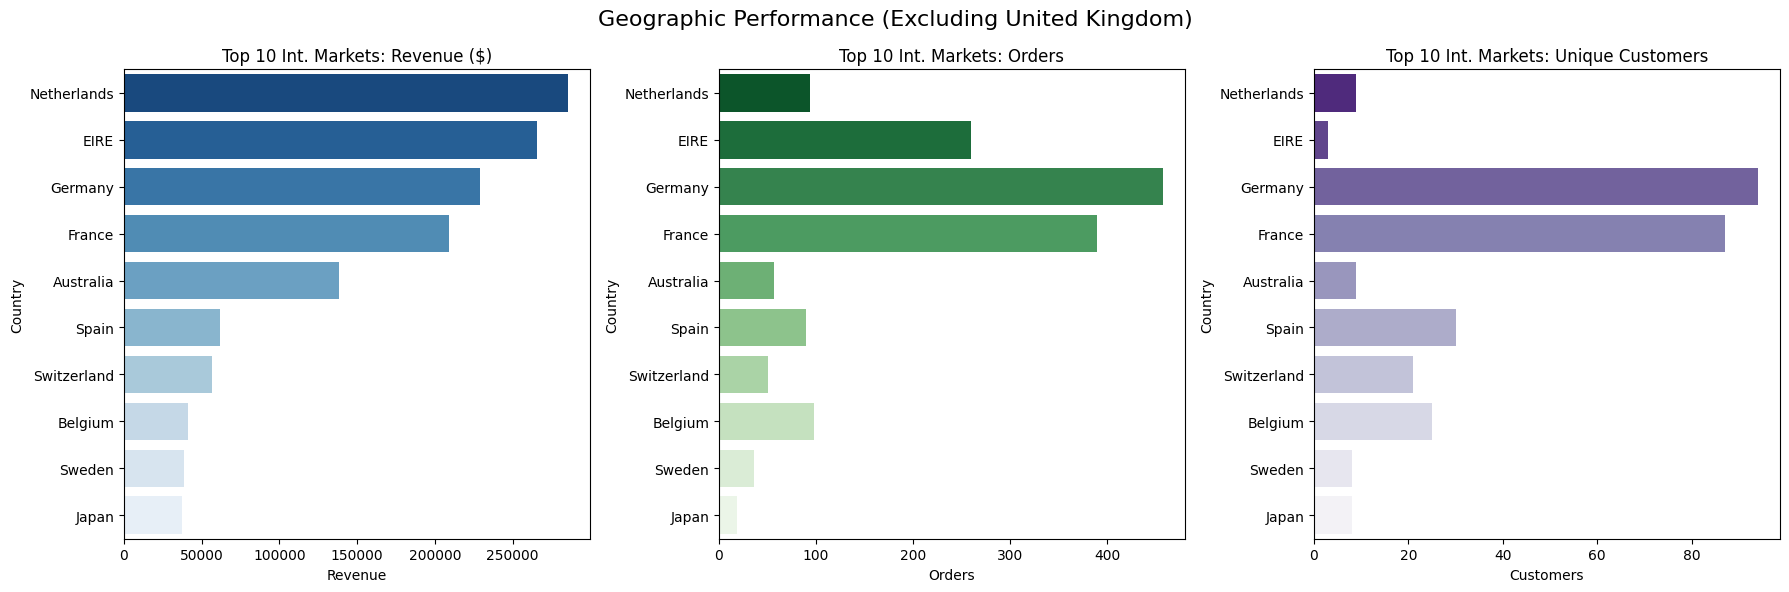

In [ ]:
# Group by country
country_metrics = sales_df.groupby('Country').agg(
    Revenue=('Revenue', 'sum'),
    Orders=('InvoiceNo', 'nunique'),
    Customers=('CustomerID', 'nunique')
).reset_index()

# Exclude UK to highlight international markets (UK dominates ~90% of data)
country_ex_uk = country_metrics[country_metrics['Country'] != 'United Kingdom'].nlargest(10, 'Revenue')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.barplot(data=country_ex_uk, y='Country', x='Revenue', ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 10 Int. Markets: Revenue ($)')

sns.barplot(data=country_ex_uk, y='Country', x='Orders', ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 10 Int. Markets: Orders')

sns.barplot(data=country_ex_uk, y='Country', x='Customers', ax=axes[2], palette='Purples_r')
axes[2].set_title('Top 10 Int. Markets: Unique Customers')

plt.suptitle('Geographic Performance (Excluding United Kingdom)', fontsize=16)
plt.tight_layout()
plt.show()

# **5. Top 5 products in top 5 international markets in revenue**

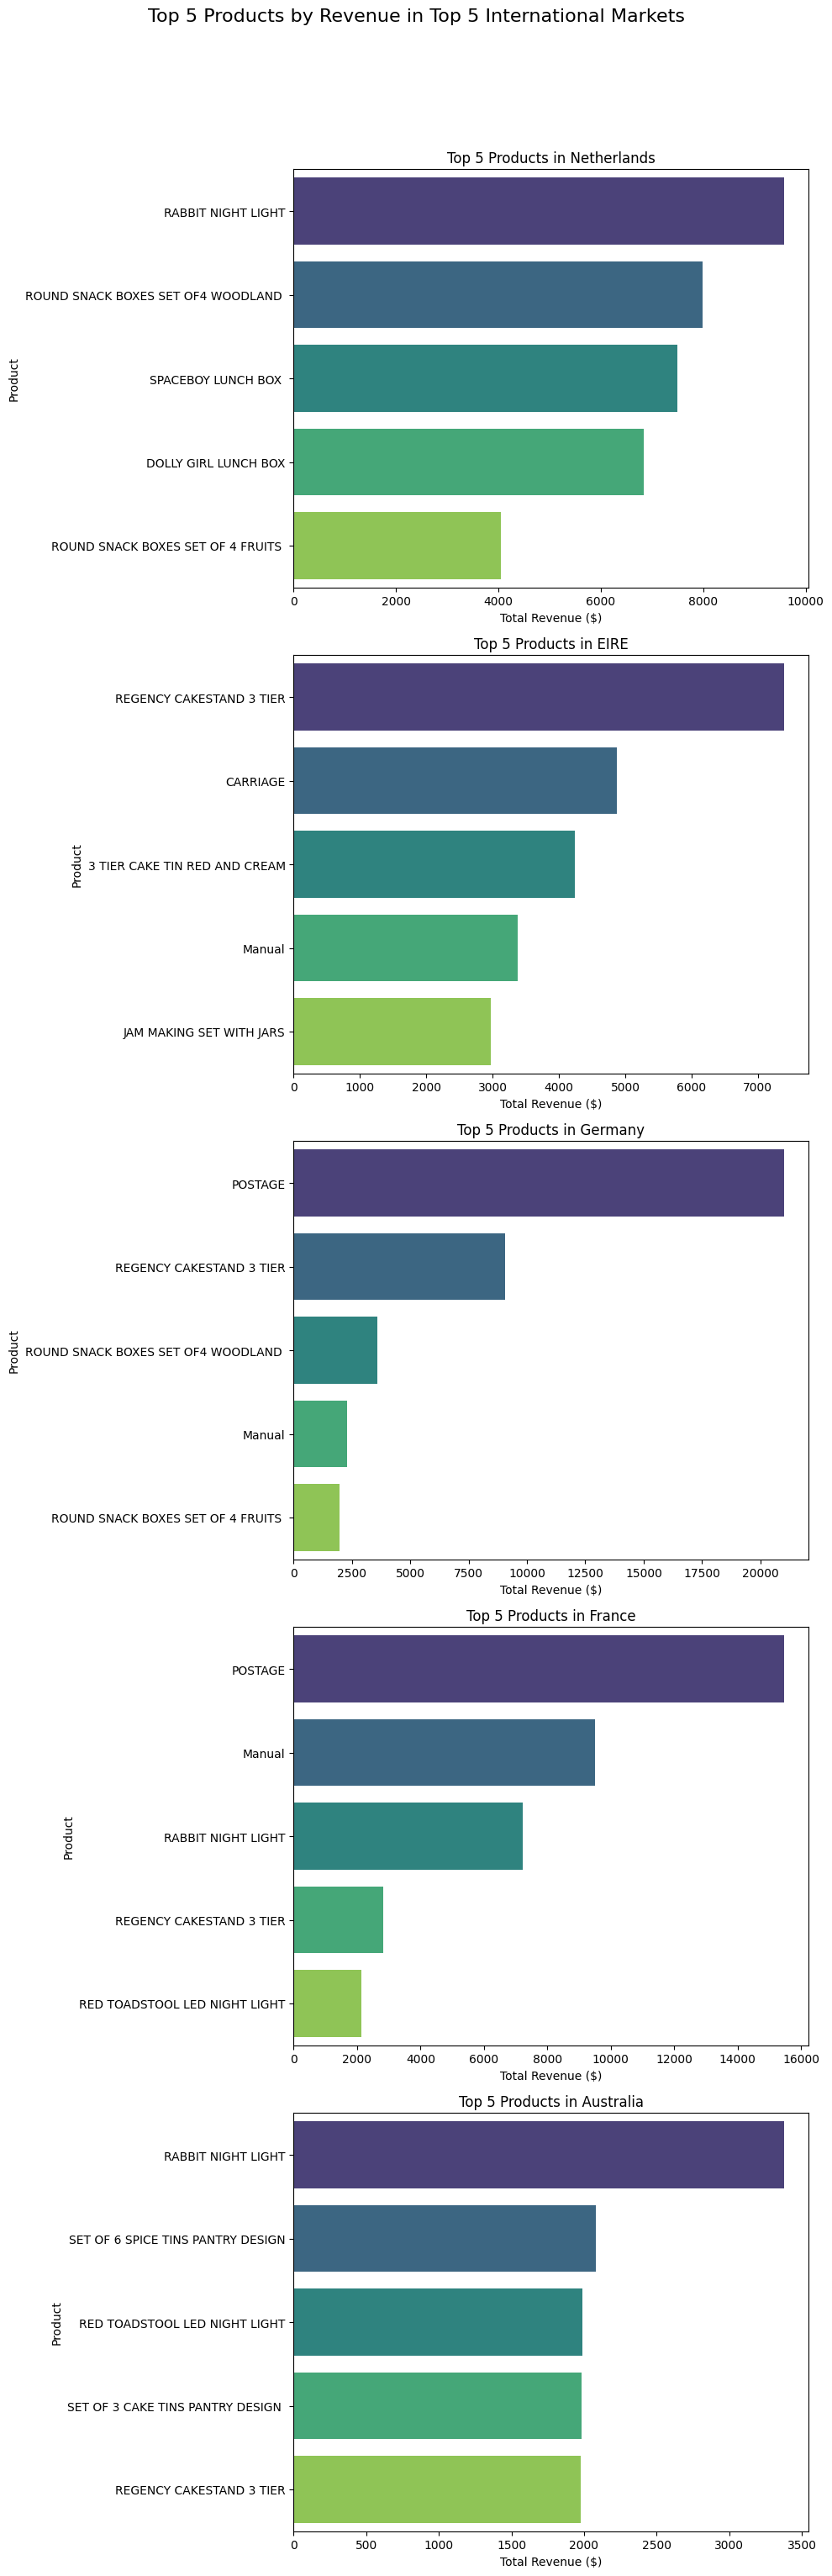

In [ ]:
prod_col = 'Description' if 'Description' in sales_df.columns else 'StockCode'

top_5_countries = country_ex_uk['Country'].head(5).tolist()

fig, axes = plt.subplots(nrows=len(top_5_countries), ncols=1, figsize=(10, 6 * len(top_5_countries)))
fig.suptitle('Top 5 Products by Revenue in Top 5 International Markets', fontsize=16, y=1.02)

for i, country in enumerate(top_5_countries):
    country_df = sales_df[sales_df['Country'] == country]
    top_products_country = country_df.groupby(prod_col)['Revenue'].sum().nlargest(5).reset_index()

    sns.barplot(data=top_products_country, y=prod_col, x='Revenue', ax=axes[i], palette='viridis', hue=prod_col, legend=False)
    axes[i].set_title(f'Top 5 Products in {country}')
    axes[i].set_xlabel('Total Revenue ($)')
    axes[i].set_ylabel('Product')

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()